In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from matplotlib.colors import ListedColormap
import math
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB

In [ ]:
# Загрузка данных
df = pd.read_csv("hypertension_dataset.csv")

In [ ]:
# Очистка и предварительная обработка данных
# Заполняем пропуски в столбце 'Medication' значением 'None' (если пациент не принимает медикаменты)
df['Medication'] = df['Medication'].fillna('None')

In [ ]:
# Преобразуем категорию истории давления в числовую шкалу:
# Normal -> 0, Prehypertension -> 1, Hypertension -> 2.
bp_history_mapping = {'Normal': 0, 'Prehypertension': 1, 'Hypertension': 2}
df['BP_History'] = df['BP_History'].map(bp_history_mapping)

In [ ]:
# Кодируем категориальные признаки с помощью one-hot.
categorical_cols = ['Family_History', 'Exercise_Level', 'Smoking_Status', 'Medication']
df = pd.get_dummies(df, columns=categorical_cols, drop_first=True, dtype=int)

In [ ]:
# Преобразуем целевую переменную в числовую: Yes -> 1, No -> 0
df['Has_Hypertension'] = df['Has_Hypertension'].map({'Yes': 1, 'No': 0})


In [ ]:
# Список колонок, которые удалим из признаков.
cols_to_drop = [col for col in [
    'Medication_Beta Blocker',
    'Medication_Other',
    'Medication_None',
    'Exercise_Level_Moderate',
    'Exercise_Level_Low',
    'Has_Hypertension'
] if col in df.columns]


In [ ]:
# Формируем X (признаки) и y (целевая переменная)
X = df.drop(cols_to_drop, axis=1)
y = df['Has_Hypertension']

In [ ]:
# Разбиваем данные на обучающую и тестовую выборки.
# stratify=y сохраняет пропорции классов в разбиении при дисбалансе классов.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


In [ ]:
# Стандартизация признаков:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
# Выбираем два признака для визуализации: 'Age' и 'BMI'
feature_name1 = 'Age'
feature_name2 = 'BMI'

In [ ]:
# Получаем индексы выбранных признаков в матрице X
feature_idx1 = X_train.columns.get_loc(feature_name1)
feature_idx2 = X_train.columns.get_loc(feature_name2)

print(f"Выбраны признаки для визуализации: '{feature_name1}' (индекс {feature_idx1}) и '{feature_name2}' (индекс {feature_idx2}).")

Выбраны признаки для визуализации: 'Age' (индекс 0) и 'BMI' (индекс 5).


In [ ]:
# Вычисляем средние значения признаков по тренировочной выборке.
# Понадобятся, чтобы зафиксировать все остальные признаки при создании 2D-сетки.
X_train_mean = X_train_scaled.mean(axis=0)

In [ ]:
def plot_decision_boundary(ax, clf, X_train_scaled, y_train, X_test_scaled, y_test,
                                  feature_idx1, feature_idx2, feature_name1, feature_name2,
                                  title, X_train_mean):
    """
    Рисует границу решений классификатора clf в пространстве двух признаков.
    Все остальные признаки фиксируются на средних значениях X_train_mean.

    Параметры:
    - ax: matplotlib.axes для рисования
    - clf: обученный классификатор (с методом predict)
    - X_train_scaled, X_test_scaled: масштабированные numpy-массивы признаков
    - y_train, y_test: метки классов
    - feature_idx1, feature_idx2: индексы двух выбранных признаков
    - feature_name1, feature_name2: имена выбранных признаков (для подписей)
    - title: заголовок графика
    - X_train_mean: средние значения признаков по тренировочной выборке
    """

    # Объединяем, чтобы получить общий диапазон для отображения
    X_combined = np.vstack((X_train_scaled, X_test_scaled))

    # Определяем границы сетки по выбранным признакам с небольшим запасом
    x_min, x_max = X_combined[:, feature_idx1].min() - 0.5, X_combined[:, feature_idx1].max() + 0.5
    y_min, y_max = X_combined[:, feature_idx2].min() - 0.5, X_combined[:, feature_idx2].max() + 0.5

    # Создаём сетку значений по двум осям (шаг 0.02)
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02), np.arange(y_min, y_max, 0.02))

    # Подготавливаем матрицу признаков:
    # дублируем средние значения по всем признакам и заменяем два выбранных признака значениями сетки
    X_grid_dummy = np.tile(X_train_mean, (xx.shape[0] * xx.shape[1], 1))
    X_grid_dummy[:, feature_idx1] = xx.ravel()
    X_grid_dummy[:, feature_idx2] = yy.ravel()

    # Предсказываем классы на подготовленной сетке
    Z = clf.predict(X_grid_dummy)
    Z = Z.reshape(xx.shape)

    # Определяем цветовые карты для фона и точек (2 класса)
    cmap_light_2class = ListedColormap(['#FFCCCC', '#CCFFCC'])  # фон: светло-красный для 0, светло-зелёный для 1
    cmap_bold_2class = ListedColormap(['#FF0000', '#00FF00'])   # точки: красный для 0, зелёный для 1

    # Рисуем области решений
    ax.contourf(xx, yy, Z, alpha=1, cmap=cmap_light_2class)

    # Рисуем точки обучающей выборки (маленькие кружки)
    ax.scatter(X_train_scaled[:, feature_idx1], X_train_scaled[:, feature_idx2],
               c=y_train, cmap=cmap_bold_2class, edgecolor='k', s=20,
               label='Train (0: No, 1: Yes)')

    # Рисуем точки тестовой выборки (большие кресты для выделения)
    ax.scatter(X_test_scaled[:, feature_idx1], X_test_scaled[:, feature_idx2],
               c=y_test, cmap=cmap_bold_2class, edgecolor='k', s=60, marker='X',
               label='Test (0: No, 1: Yes)')

    # Подписываем оси и заголовок
    ax.set_xlabel(f"{feature_name1} (standardized)")
    ax.set_ylabel(f"{feature_name2} (standardized)")
    ax.set_title(title)
    ax.legend()

## Выбор представленных классификаторов обусловлен их разнообразием, популярностью и способностью решать широкий спектр задач классификации. Они представляют собой хороший набор базовых моделей, позволяющих исследовать различные подходы к моделированию данных.

1. **Logistic Regression (Логистическая регрессия):**
    *   Является простым, быстрым и хорошо интерпретируемым классификатором. Он отлично подходит для бинарной классификации. Логистическая регрессия служит хорошей базовой линией (baseline) для сравнения с более сложными моделями.
  
2. **SVM (Support Vector Machine - Метод опорных векторов):**
    *   SVM известны своей способностью работать в высокоразмерных пространствах и находить оптимальную разделяющую гиперплоскость.
        *   SVM (Linear): Хорош для линейно разделимых данных, обеспечивает быструю тренировку и высокую интерпретируемость (в смысле обнаружения линейных зависимостей).
        *   SVM (RBF - Radial Basis Function kernel): Позволяет работать с нелинейно разделимыми данными, используя преобразование в более высокие измерения. RBF-ядро является мощным и универсальным.
   
3. **Decision Tree (Дерево решений):**
    *   Дерево решений легко интерпретируемый алгоритм, который может захватывать сложные зависимости в данных. Оно разбивает пространство признаков на прямоугольные области, что может быть полезно для некоторых типов данных.
    

4. **K-Nearest Neighbors (KNN - Метод k-ближайших соседей):**
    *   Непараметрический метод, который учитывает локальную структуру данных. Разные значения k позволяют оценить влияние числа соседей на качество классификации.
   

5. **Random Forest (Случайный лес):**
    *   Ансамблевый метод, который объединяет несколько деревьев решений для улучшения точности и устойчивости к переобучению. Хорошо работает с высокоразмерными данными.

6. **Naive Bayes (Наивный Байес):**
    *   Основан на теореме Байеса с наивным предположением о независимости признаков. Он очень быстр, требует мало данных для обучения и хорошо работает при наличии независимых признаков.
  


In [ ]:
# Инициализация классификаторов
classifiers = {
    "Logistic Regression": LogisticRegression(random_state=42),
    "SVM (Linear)": SVC(kernel='linear', random_state=42),
    "SVM (RBF)": SVC(kernel='rbf', random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "K-Nearest Neighbors (k=5)": KNeighborsClassifier(n_neighbors=5),
    "K-Nearest Neighbors (k=10)": KNeighborsClassifier(n_neighbors=10),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Naive Bayes": GaussianNB()
}


 Построение границ решений 
Обучение Logistic Regression
Обучение SVM (Linear)
Обучение SVM (RBF)
Обучение Decision Tree
Обучение K-Nearest Neighbors (k=5)
Обучение K-Nearest Neighbors (k=10)
Обучение Random Forest
Обучение Naive Bayes


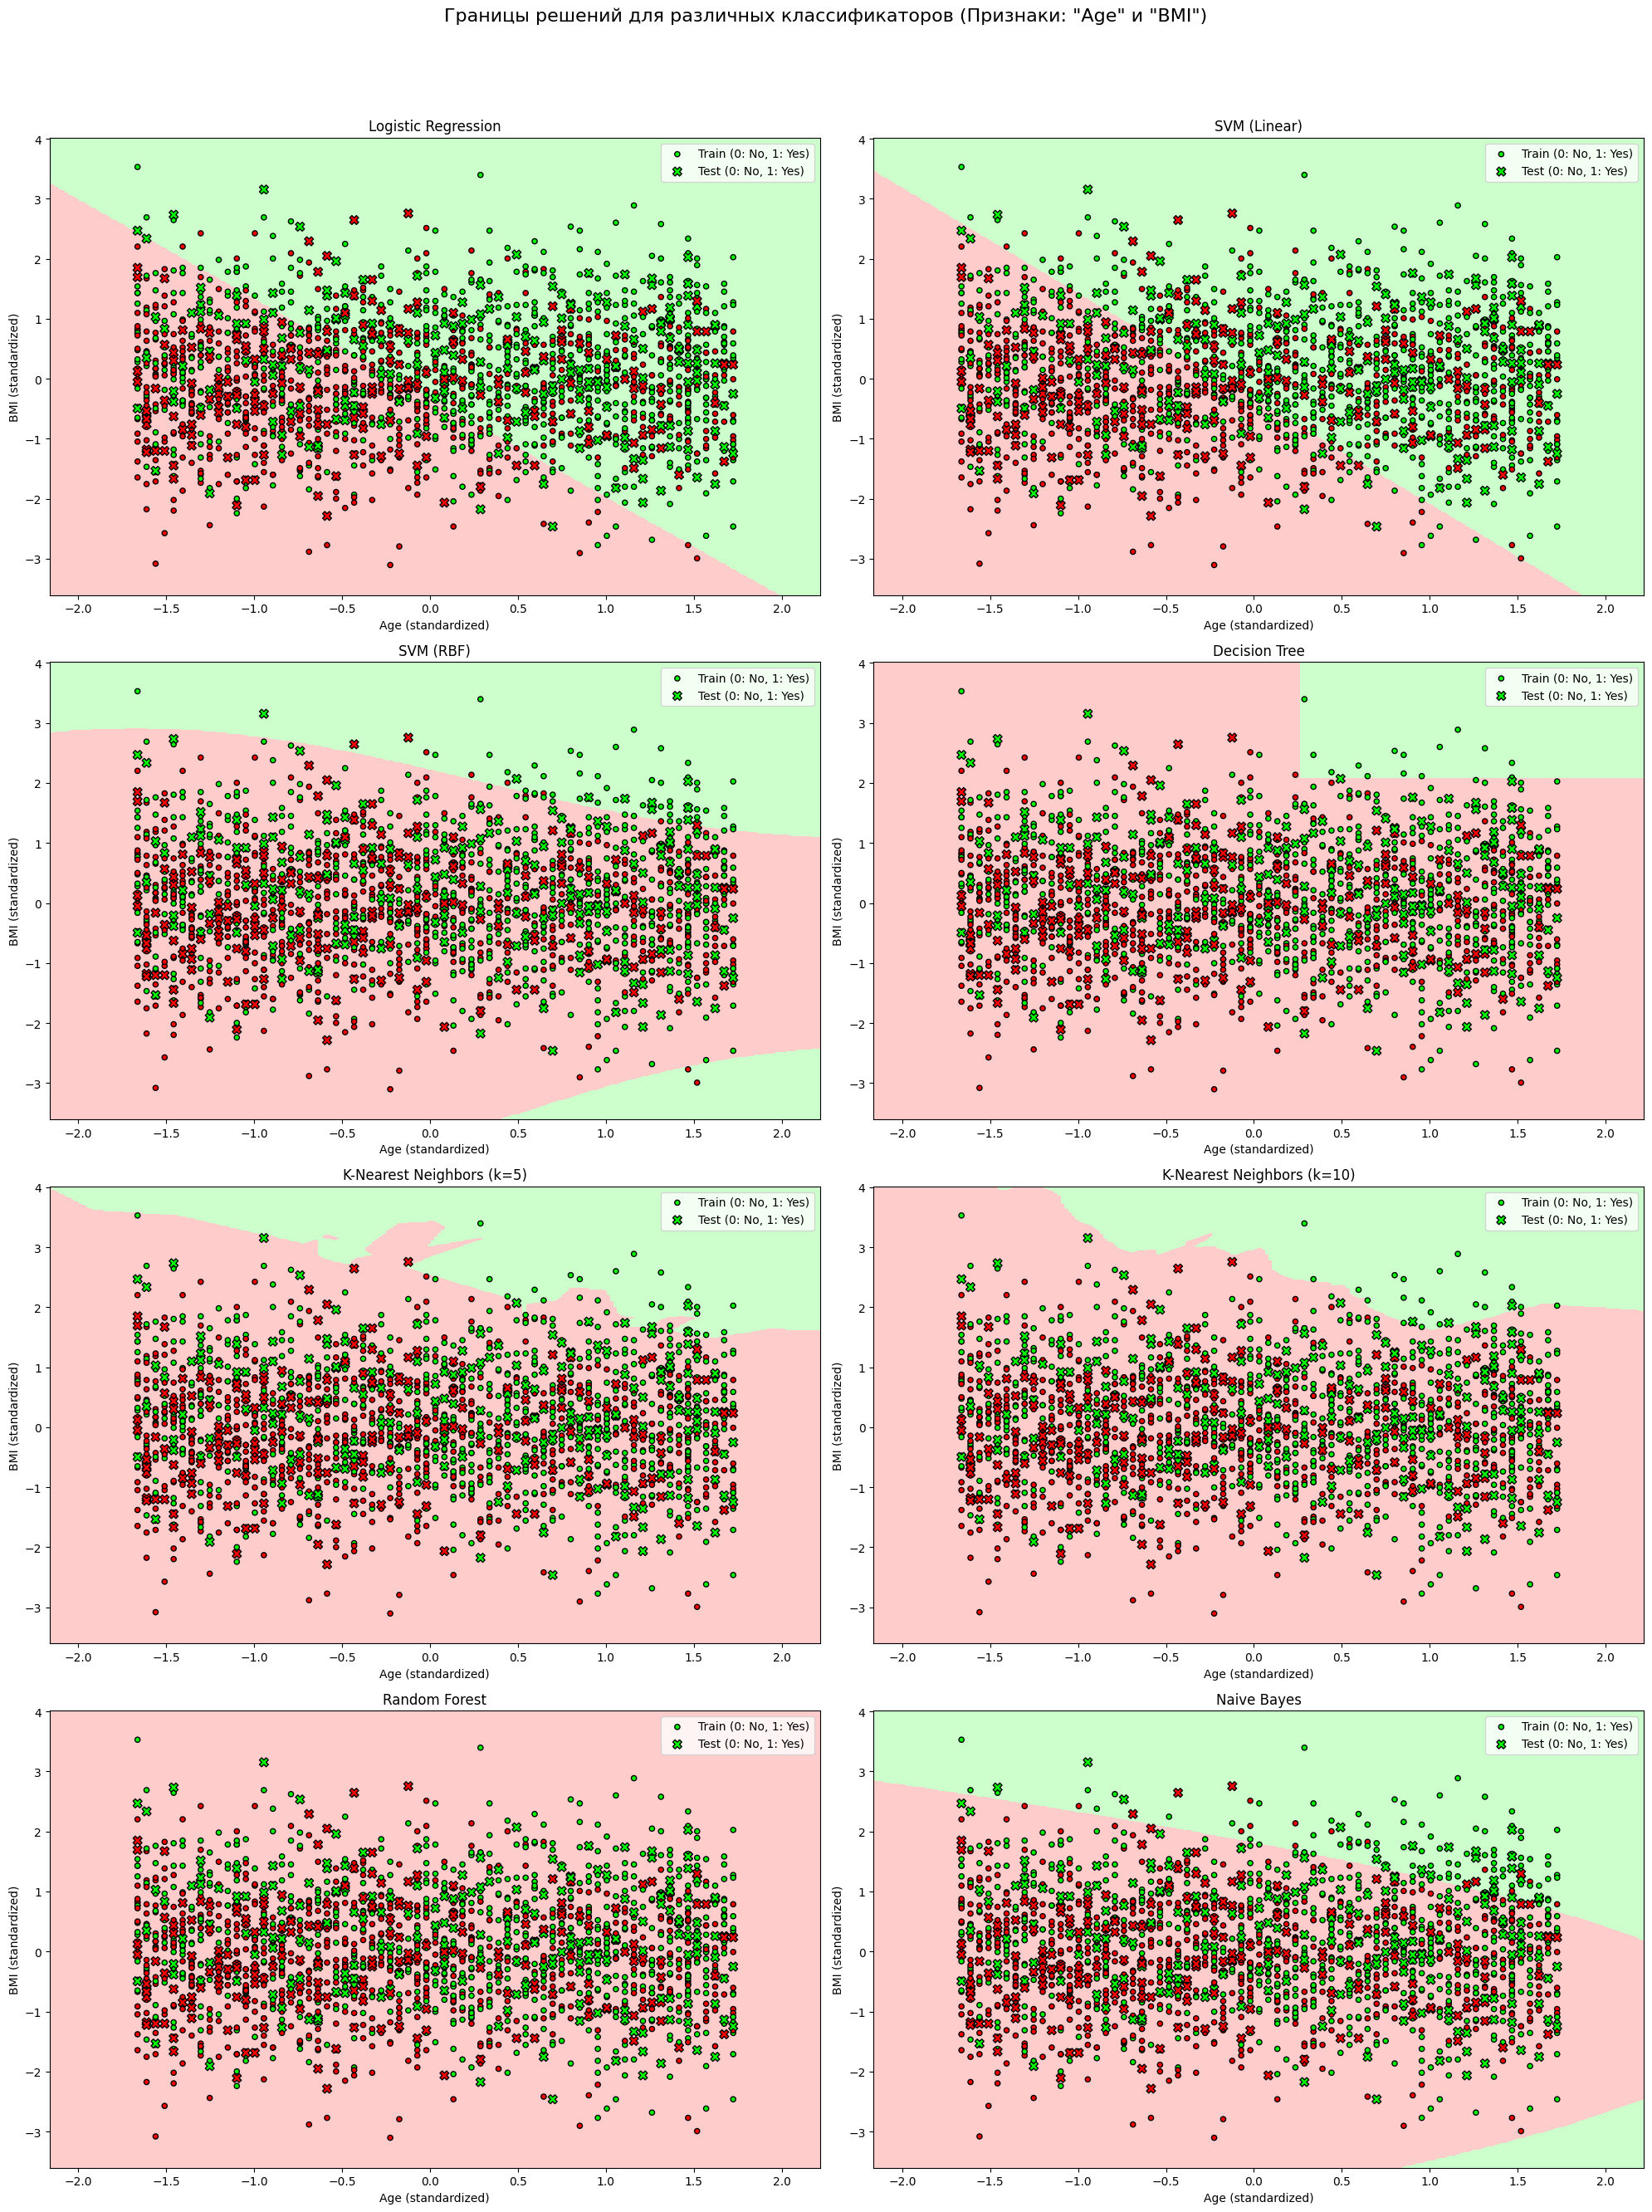

In [ ]:
# Построение границ решений
n_classifiers = len(classifiers)
n_cols = 2
n_rows = math.ceil(n_classifiers / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 7 * n_rows))
axes = axes.flatten()

fig.suptitle(f'Границы решений для различных классификаторов (Признаки: "{feature_name1}" и "{feature_name2}")', fontsize=16)

for i, (name, clf) in enumerate(classifiers.items()):
    ax = axes[i]
    clf.fit(X_train_scaled, y_train)
    # Вызываем функцию отрисовки
    plot_decision_boundary(ax, clf, X_train_scaled, y_train, X_test_scaled, y_test,
                                  feature_idx1, feature_idx2, feature_name1, feature_name2,
                                  f'{name}',
                                  X_train_mean)

# Отключаем любые неиспользуемые сабплоты, если количество классификаторов нечетное
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Регулируем отступы, чтобы уместился fig.suptitle
plt.show()

# **Границы решений для различных классификаторов на графиках**

## **Logistic Regression (Логистическая регрессия)**
Логистическая регрессия формирует линейную границу между классами — на графике видна почти прямая линия, отделяющая одну область от другой, но данные не являются идеально линейно разделимыми, поэтому многие точки одного класса попадают в область другого класса.

## **SVM (Linear) (Support Vector Machine с линейным ядром)**  
Похоже на логистическую регрессию: граница почти прямая, поскольку классификатор также ищет оптимальное линейное разделение, но чуть-чуть отличается угол наклона и смещение прямой, так как SVM максимизирует зазор между классами (margin).

## **SVM (RBF) (SVM с гауссовым (RBF) ядром)**
Граница становится криволинейной и “мягче” подстраивается к форме данных, захватывая небольшие “островки” одного класса в другой области. Модель может улавливать сложные нелинейные зависимости.

## **Decision Tree (Дерево решений)**
Граница имеет характерные для деревьев “прямоугольные” ступенчатые границы, потому что дерево решений делит пространство по порогам признаков (по вертикальной и горизонтальной осям). Границы могут быть сложными, но выглядят как комбинация прямых, параллельных осям признаков.

## **K-Nearest Neighbors (k=5) (k-ближайших соседей, k=5)**  
Граница сложной формы, повторяет контуры облаков точек различных классов; "локальная" сегментация пространства. KNN классифицирует новую точку на основе большинства классов среди k ближайших соседей. При k=5 граница решений очень чувствительна к локальному распределению данных и может быть очень "шумной" и фрагментированной, создавая маленькие "острова" одного класса внутри другого.

## **K-Nearest Neighbors (k=10) (k-ближайших соседей, k=10)**
Увеличение k до 10 делает классификатор менее чувствительным к шуму и выбросам, поскольку для принятия решения учитывается больше соседей. Граница решений становится более сглаженной, менее фрагментированной, чем при k=5, но по-прежнему способна улавливать нелинейные паттерны.

## **Random Forest (Случайный лес)**
Границы решений тоже “рваные” и локально сложные, но за счёт усреднения большого числа деревьев выглядят более сглаженными по сравнению с одиночным деревом. Классификатор способен улавливать сложные нелинейные зависимости.

## **Naive Bayes (Наивный Байесовский классификатор)**
Граница решений имеет простую, сглаженную и неестественно вытянутую форму — это связано с предположением о независимости признаков и использовании вероятностной модели. На графике граница выглядит как плавная кривая, которая пытается разделить данные.

